# Workshop 7

### 1: Delay comparison of FMUX and TDMA







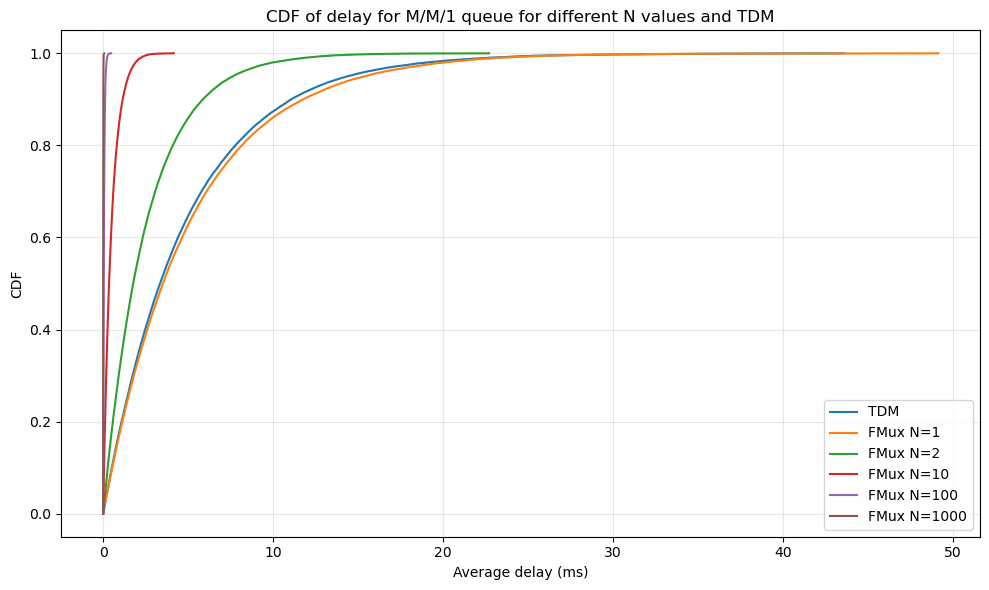

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters for M/M/1 queue
lambda_rate = 0.6  # arrivals per milli second
mu_rate =   0.8   # services per milli second
N_values = [1, 2 , 10, 100,1000]  # different values of N

# Simulation parameters
num_sims = 100000
rng = np.random.default_rng(42)  # reproducible


def simulate_mm1_queue(lambda_rate, mu_rate, num_sims, rng=None):
    """Simulate M/M/1 system times, then scale to 'round trip'."""
    if rng is None:
        rng = np.random.default_rng()

    inter_arrival = rng.exponential(1 / lambda_rate, num_sims)
    service_times = rng.exponential(1 / mu_rate, num_sims)

    # Arrival times (cumulative sum of inter-arrivals) 
    arrival_times = np.cumsum(inter_arrival)

    # Departure times (recursive single-server queue)
    departure_times = np.empty(num_sims)
    departure_times[0] = arrival_times[0] + service_times[0]
    for i in range(1, num_sims):
        departure_times[i] = max(arrival_times[i], departure_times[i - 1]) + service_times[i]

    # time spent in the system = departure - arrival (includes wait + service)
    system_times = departure_times - arrival_times

    
    return  system_times #Delay

def ecdf(data):
    """Return x,y for an empirical CDF."""
    x = np.sort(data)
    n = len(x)
    y = np.arange(0, n ) / n
    return x, y

# Simulate baseline
round_trip_times_TDM = simulate_mm1_queue(lambda_rate, mu_rate, num_sims, rng=rng)


plt.figure(figsize=(10, 6))

# TDM ECDF
x, y = ecdf(round_trip_times_TDM)
plt.step(x , y, where='post', label='TDM')  # convert to ms for plotting

# SM ECDFs for different N values
for N in N_values:
    round_trip_times_FMux = simulate_mm1_queue(N * lambda_rate, N * mu_rate, num_sims, rng=rng)
    x, y = ecdf(round_trip_times_FMux)
    plt.step(x , y, where='post', label=f'FMux N={N}')

plt.title('CDF of delay for M/M/1 queue for different N values and TDM')
plt.xlabel('Average delay (ms)')
plt.ylabel('CDF')
plt.legend()
plt.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()


### Observations 

* **Baseline (TDM):** 
* **FMux with $N=1$:** 
* **Increasing $N$:** 
* **CDF behavior:** 
* **Percentile view:** 
* **Bottom line:** 


### Compare Simulation with the Theoretical equation

In [3]:
#Compare to Theory eqn
threshold = 2.0  # ms

# TDM
p_tdm = np.mean(round_trip_times_TDM > threshold)
print(f"TDM: P(delay > {threshold} ms) = {p_tdm:.6f}")

# FMux
for N in N_values:
    round_trip_times_FMux = simulate_mm1_queue(N * lambda_rate, N * mu_rate, num_sims, rng=rng)
    p_fmux = np.mean(round_trip_times_FMux > threshold)
    print(f"FMux N={N}: P(delay > {threshold} ms) = {p_fmux:.6f}")

#For the case of some N
N= 1 
np.exp(-(N*mu_rate - N*lambda_rate) * threshold)

TDM: P(delay > 2.0 ms) = 0.661810
FMux N=1: P(delay > 2.0 ms) = 0.676580
FMux N=2: P(delay > 2.0 ms) = 0.452520
FMux N=10: P(delay > 2.0 ms) = 0.018820
FMux N=100: P(delay > 2.0 ms) = 0.000000
FMux N=1000: P(delay > 2.0 ms) = 0.000000


0.6703200460356392

#### After confirming Simulation with the Theoretical equation use code below to get the optimal service rate when the arrival rate is fixed. 

<>:26: SyntaxWarning: invalid escape sequence '\m'
<>:26: SyntaxWarning: invalid escape sequence '\l'
<>:26: SyntaxWarning: invalid escape sequence '\m'
<>:26: SyntaxWarning: invalid escape sequence '\l'
C:\Users\gayathri\AppData\Local\Temp\ipykernel_29604\2565362.py:26: SyntaxWarning: invalid escape sequence '\m'
  plt.plot(t,Prob_delay_exceed_t , label=f"$\mu$  = {mu}, $\lambda=1$")
C:\Users\gayathri\AppData\Local\Temp\ipykernel_29604\2565362.py:26: SyntaxWarning: invalid escape sequence '\l'
  plt.plot(t,Prob_delay_exceed_t , label=f"$\mu$  = {mu}, $\lambda=1$")


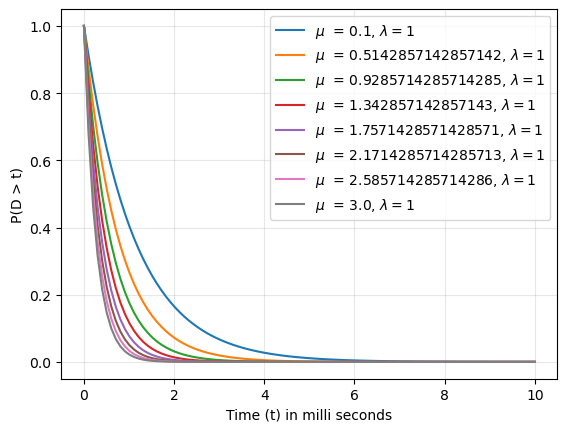

In [40]:
import numpy as np
import matplotlib.pyplot as plt

# Define the function P(D > t) = e^(-(µ* - λ)t)
def prob(t, N,  mu, lambda_rate):
    mu_star =  mu + (N-1)*lambda_rate
    Prob_delay_exceed_t = np.exp(-(mu_star - lambda_rate) * t)
    
    return Prob_delay_exceed_t

# Define the time range in milliseconds
t = np.linspace(0, 10, 100)
Prob_delay_exceed_t_mus = [ ]
#  lambda
lambda_rate = 0.1

# service rate

alpha =1
# Define a range of N values
#N_values = np.linspace(2, 10, 5)
mu_values = np.linspace(0.1, 3, 8)
# Plot the function for each N value
for mu in mu_values:
    Prob_delay_exceed_t=prob(t, N, mu, lambda_rate)
    plt.plot(t,Prob_delay_exceed_t , label=f"$\mu$  = {mu}, $\lambda=1$")
    Prob_delay_exceed_t_mus.append(Prob_delay_exceed_t)

# Add labels and legend
plt.xlabel("Time (t) in milli seconds")
plt.ylabel("P(D > t)")
plt.legend()
plt.grid(True, alpha=0.3)
# Show the plot
plt.show()





In [38]:
#From Theory
lambda_rate = 0.5
alpha = 0.1
t = 1
mu_star_min = lambda_rate - np.log(alpha) / t
mu_star_min

2.8025850929940455